# Задание 1. Сформировать отчёт с информацией о 10 наиболее популярных языках программирования по итогам года за период с 2010 по 2020 годы.

Установка Java и Apache Spark

In [1]:
!apt-get update -qq > /dev/null 2>&1
!apt-get install openjdk-11-jdk-headless -y -qq > /dev/null 2>&1
!wget --show-progress -q http://archive.apache.org/dist/spark/spark-3.5.1/spark-3.5.1-bin-hadoop3.tgz -O spark.tgz
!tar xf spark.tgz -C /content/ > /dev/null
!pip install -q findspark

spark.tgz           100%[===================>] 381.90M  17.6MB/s    in 23s     


Настройка переменных окружения для Spark

In [2]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.1-bin-hadoop3"
os.environ["PYSPARK_PYTHON"] = "/usr/bin/python3"
os.environ["PYSPARK_SUBMIT_ARGS"] = "--packages com.databricks:spark-xml_2.12:0.17.0 pyspark-shell"

Создание SparkSession

In [3]:
import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.builder.getOrCreate()
spark

Скачивание датасета с языками программирования (CSV)

In [4]:
!wget -O programming-languages.csv https://git.ai.ssau.ru/tk/big_data/raw/352021f75c1d91b3bc10c22731a36bb5aaf1f529/data/programming-languages.csv

--2026-04-19 14:43:24--  https://git.ai.ssau.ru/tk/big_data/raw/352021f75c1d91b3bc10c22731a36bb5aaf1f529/data/programming-languages.csv
Resolving git.ai.ssau.ru (git.ai.ssau.ru)... 91.222.131.161
Connecting to git.ai.ssau.ru (git.ai.ssau.ru)|91.222.131.161|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: /tk/big_data/raw/commit/352021f75c1d91b3bc10c22731a36bb5aaf1f529/data/programming-languages.csv [following]
--2026-04-19 14:43:25--  https://git.ai.ssau.ru/tk/big_data/raw/commit/352021f75c1d91b3bc10c22731a36bb5aaf1f529/data/programming-languages.csv
Reusing existing connection to git.ai.ssau.ru:443.
HTTP request sent, awaiting response... 200 OK
Length: 40269 (39K) [text/plain]
Saving to: ‘programming-languages.csv’

programming-languag 100%[===================>]  39.33K   113KB/s    in 0.3s    

2026-04-19 14:43:26 (113 KB/s) - ‘programming-languages.csv’ saved [40269/40269]



Скачивание датасета Stack Overflow (XML)

In [5]:
!wget -O posts_sample.xml https://git.ai.ssau.ru/tk/big_data/raw/352021f75c1d91b3bc10c22731a36bb5aaf1f529/data/posts_sample.xml

--2026-04-19 14:43:26--  https://git.ai.ssau.ru/tk/big_data/raw/352021f75c1d91b3bc10c22731a36bb5aaf1f529/data/posts_sample.xml
Resolving git.ai.ssau.ru (git.ai.ssau.ru)... 91.222.131.161
Connecting to git.ai.ssau.ru (git.ai.ssau.ru)|91.222.131.161|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: /tk/big_data/raw/commit/352021f75c1d91b3bc10c22731a36bb5aaf1f529/data/posts_sample.xml [following]
--2026-04-19 14:43:27--  https://git.ai.ssau.ru/tk/big_data/raw/commit/352021f75c1d91b3bc10c22731a36bb5aaf1f529/data/posts_sample.xml
Reusing existing connection to git.ai.ssau.ru:443.
HTTP request sent, awaiting response... 200 OK
Length: 74162295 (71M) [text/plain]
Saving to: ‘posts_sample.xml’

posts_sample.xml    100%[===================>]  70.73M   426KB/s    in 2m 6s   

2026-04-19 14:45:34 (573 KB/s) - ‘posts_sample.xml’ saved [74162295/74162295]



In [6]:
postsData = spark.read.format('xml') \
                      .option('rowTag', 'row') \
                      .option("timestampFormat", 'y/M/d H:m:s') \
                      .load('/content/posts_sample.xml')
postsData.count()

46006

In [7]:
postsData.show(5)

+-----------------+------------+--------------------+-----------+-------------+--------------------+--------------------+--------------+---+--------------------+--------------------+----------------------+-----------------+-----------------+------------+---------+-----------+------+--------------------+--------------------+----------+
|_AcceptedAnswerId|_AnswerCount|               _Body|_ClosedDate|_CommentCount| _CommunityOwnedDate|       _CreationDate|_FavoriteCount|_Id|   _LastActivityDate|       _LastEditDate|_LastEditorDisplayName|_LastEditorUserId|_OwnerDisplayName|_OwnerUserId|_ParentId|_PostTypeId|_Score|               _Tags|              _Title|_ViewCount|
+-----------------+------------+--------------------+-----------+-------------+--------------------+--------------------+--------------+---+--------------------+--------------------+----------------------+-----------------+-----------------+------------+---------+-----------+------+--------------------+--------------------+-

Фильтрация постов за период 2010-2020 гг.

In [8]:
import pyspark.sql.functions as F

dates = ("2010-01-01",  "2020-12-31")
posts_by_date = postsData.filter(F.col("_CreationDate").between(*dates))
posts_by_date.show(5)

+-----------------+------------+--------------------+-----------+-------------+-------------------+--------------------+--------------+-------+--------------------+--------------------+----------------------+-----------------+-----------------+------------+---------+-----------+------+-----+------+----------+
|_AcceptedAnswerId|_AnswerCount|               _Body|_ClosedDate|_CommentCount|_CommunityOwnedDate|       _CreationDate|_FavoriteCount|    _Id|   _LastActivityDate|       _LastEditDate|_LastEditorDisplayName|_LastEditorUserId|_OwnerDisplayName|_OwnerUserId|_ParentId|_PostTypeId|_Score|_Tags|_Title|_ViewCount|
+-----------------+------------+--------------------+-----------+-------------+-------------------+--------------------+--------------+-------+--------------------+--------------------+----------------------+-----------------+-----------------+------------+---------+-----------+------+-----+------+----------+
|             NULL|        NULL|<p>No. (And more ...|       NULL|  

In [9]:
languagesData = spark.read.format('csv') \
                          .option('header', 'true') \
                          .option("inferSchema", True) \
                          .load('/content/programming-languages.csv') \
                          .dropna()
languagesData.count()

699

In [10]:
languagesData.show(5)

+----------+--------------------+
|      name|       wikipedia_url|
+----------+--------------------+
|   A# .NET|https://en.wikipe...|
|A# (Axiom)|https://en.wikipe...|
|A-0 System|https://en.wikipe...|
|        A+|https://en.wikipe...|
|       A++|https://en.wikipe...|
+----------+--------------------+
only showing top 5 rows



Обработка данных: поиск упоминаний языков в тегах и группировка по годам

In [11]:
language_names = [str(x[0]) for x in languagesData.collect()]

def includes_name(x):
    tag = None
    for name in language_names:
        n = '<' + name.lower() + '>'
        if n in str(x._Tags).lower():
            tag = name
            break
    if tag is None:
        tag = 'No'

    return (x[6], tag)

posts_by_date_rdd = posts_by_date.rdd.map(includes_name).filter(lambda x: x[1] != 'No')

posts_by_date_rdd_group = posts_by_date_rdd.keyBy(lambda row: (row[0].year, row[1])) \
                          .aggregateByKey(0, lambda x, y: x + 1, lambda x1, x2: x1 + x2) \
                          .sortBy(lambda x: x[1], ascending=False).collect()

years_list = [i for i in range(2010, 2020)][::-1]
df_by_years = []
for year in years_list:
    df_by_years.extend([row for row in posts_by_date_rdd_group if row[0][0] == year][:10])


Создание DataFrame с топ-10 языками за каждый год

In [12]:
from pyspark.sql import Row

row_template = Row('Year', 'Language', 'Count')
result_df = spark.createDataFrame([row_template(*x, y) for x, y in df_by_years])
result_df.show(120)

+----+-----------+-----+
|Year|   Language|Count|
+----+-----------+-----+
|2019|     Python|  162|
|2019| JavaScript|  131|
|2019|       Java|   95|
|2019|        PHP|   59|
|2019|          R|   36|
|2019|          C|   14|
|2019|       Dart|    9|
|2019|     MATLAB|    9|
|2019|         Go|    9|
|2019|       Bash|    8|
|2018|     Python|  214|
|2018| JavaScript|  196|
|2018|       Java|  145|
|2018|        PHP|   99|
|2018|          R|   63|
|2018|          C|   24|
|2018|      Scala|   22|
|2018| TypeScript|   21|
|2018| PowerShell|   13|
|2018|       Bash|   12|
|2017| JavaScript|  244|
|2017|       Java|  204|
|2017|     Python|  185|
|2017|        PHP|  122|
|2017|          R|   53|
|2017|          C|   24|
|2017|Objective-C|   19|
|2017|       Ruby|   16|
|2017| TypeScript|   14|
|2017| PowerShell|   14|
|2016| JavaScript|  272|
|2016|       Java|  179|
|2016|     Python|  141|
|2016|        PHP|  126|
|2016|          R|   50|
|2016|          C|   32|
|2016|       Ruby|   21|


# Задание 2. Получившийся отчёт сохранить в формате Apache Parquet.

In [13]:
result_df.write.mode("overwrite").parquet('/content/top_ten_languages.parquet')

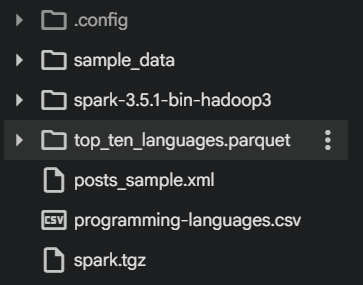